# **SETUP & IMPORT LIBRARIES**

In [ ]:
# Install required libraries
!pip install wordcloud sastrawi openpyxl -q

import pandas as pd
import numpy as np
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("✓ pandas, numpy")

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

print("✓ matplotlib, seaborn, wordcloud")

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

print("✓ Sastrawi (Stemmer, StopWordRemover)")

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

%matplotlib inline

print("\n✓ Semua library berhasil diimport!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.4 MB/s eta 0:00:00
✓ pandas, numpy
✓ matplotlib, seaborn, wordcloud
✓ Sastrawi (Stemmer, StopWordRemover)

✓ Semua library berhasil diimport!


# **DATA LOADING**

In [ ]:
# Read CSV
file_name = 'dataprepo.csv'
df_raw = pd.read_csv(file_name)

print(f"✓ Data berhasil dibaca dari: {file_name}")
print(f"\n📊 Informasi Dataset:")
print(f"   • Total baris  : {df_raw.shape[0]:,} review")
print(f"   • Total kolom  : {df_raw.shape[1]} kolom")

# Tampilkan nama kolom
print(f"\n📋 Daftar Kolom ({len(df_raw.columns)} kolom):")
for i, col in enumerate(df_raw.columns, 1):
    print(f"   {i:2d}. {col}")

# Tampilkan info tipe data
print(f"\n📊 Tipe Data Kolom:")
print(df_raw.dtypes)

✓ Data berhasil dibaca dari: dataprepo.csv

📊 Informasi Dataset:
   • Total baris  : 2,657 review
   • Total kolom  : 2 kolom

📋 Daftar Kolom (2 kolom):
    1. content
    2. at

📊 Tipe Data Kolom:
content    object
at         object
dtype: object


# **EXPLORATORY DATA ANALYSIS (EDA)**

In [ ]:
import re
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# ── Feature Engineering ──────────────────────────────────────────
df = df_raw.copy()
df['at']          = pd.to_datetime(df['at'], errors='coerce')
df['char_length'] = df['content'].fillna('').apply(len)
df['word_count']  = df['content'].fillna('').apply(lambda x: len(str(x).split()))
df['year']        = df['at'].dt.year
df['month']       = df['at'].dt.month

print("✓ Feature engineering selesai")
print(df[['content', 'char_length', 'word_count']].head(5))

✓ Feature engineering selesai
                                                 content  char_length  \
0            setiap mau masuk ke beranda selalu loadingg           43   
1                                 Aplikasi RS terbaik...           22   
2  aplikasi lengkap, fitur andalan dan sangat informatif           53   
3                                                     ok            2   
4                                                   good            4   

   word_count  
0           7  
1           3  
2           7  
3           1  
4           1  


In [ ]:
# ── Missing Values Check ─────────────────────────────────────────
missing_count = df['content'].isnull().sum()
missing_pct   = (missing_count / len(df)) * 100

print(f"\n🔍 Missing Values:")
print(f"   Missing: {missing_count:,} ({missing_pct:.2f}%)")

if missing_count > 0:
    print(f"\n⚠️  Ditemukan {missing_count} review kosong/null")
else:
    print(f"\n✓ Tidak ada missing values")


🔍 Missing Values:
   Missing: 0 (0.00%)

✓ Tidak ada missing values


**Word Count Distribution**

In [ ]:
# ── Word Count Distribution ───────────────────────────────────────
word_dist = df['word_count'].value_counts().sort_index()

print(f"\n📊 Distribusi Review Berdasarkan Jumlah Kata:")
print(f"   {'Words':10s} {'Count':>10s} {'Percentage':>12s}")
print("   " + "-" * 34)

for words in range(1, min(11, word_dist.index.max() + 1)):
    if words in word_dist.index:
        count = word_dist[words]
        pct   = (count / len(df)) * 100
        print(f"   {words:2d} kata    {count:>10,} {pct:>11.2f}%")

if word_dist.index.max() > 10:
    remaining     = word_dist[word_dist.index > 10].sum()
    pct_remaining = (remaining / len(df)) * 100
    print(f"   {'11+ kata':10s} {remaining:>10,} {pct_remaining:>11.2f}%")

reviews_1_word = (df['word_count'] < 2).sum()
pct_1_word     = (reviews_1_word / len(df)) * 100
print(f"\n⚠️  Review dengan < 2 kata: {reviews_1_word:,} ({pct_1_word:.2f}%)")

if reviews_1_word > 0:
    print(f"\n📝 Contoh review < 2 kata:")
    examples = df[df['word_count'] < 2]['content'].head(10)
    for i, text in enumerate(examples, 1):
        print(f"   {i:2d}. '{text}'")


📊 Distribusi Review Berdasarkan Jumlah Kata:
   Words           Count   Percentage
   ----------------------------------
    1 kata           560       21.08%
    2 kata           392       14.75%
    3 kata           220        8.28%
    4 kata           175        6.59%
    5 kata           159        5.98%
    6 kata           124        4.67%
    7 kata           108        4.06%
    8 kata            78        2.94%
    9 kata            64        2.41%
   10 kata            68        2.56%
   11+ kata          709       26.68%

⚠️  Review dengan < 2 kata: 560 (21.08%)

📝 Contoh review < 2 kata:
    1. 'ok'
    2. 'good'
    3. 'Bagus'
    4. 'ok'
    5. 't..o...p'
    6. 'ok'
    7. 'nice'
    8. 'okok'
    9. 'baguss'
   10. 'oke😀'


**Visualisasi EDA**

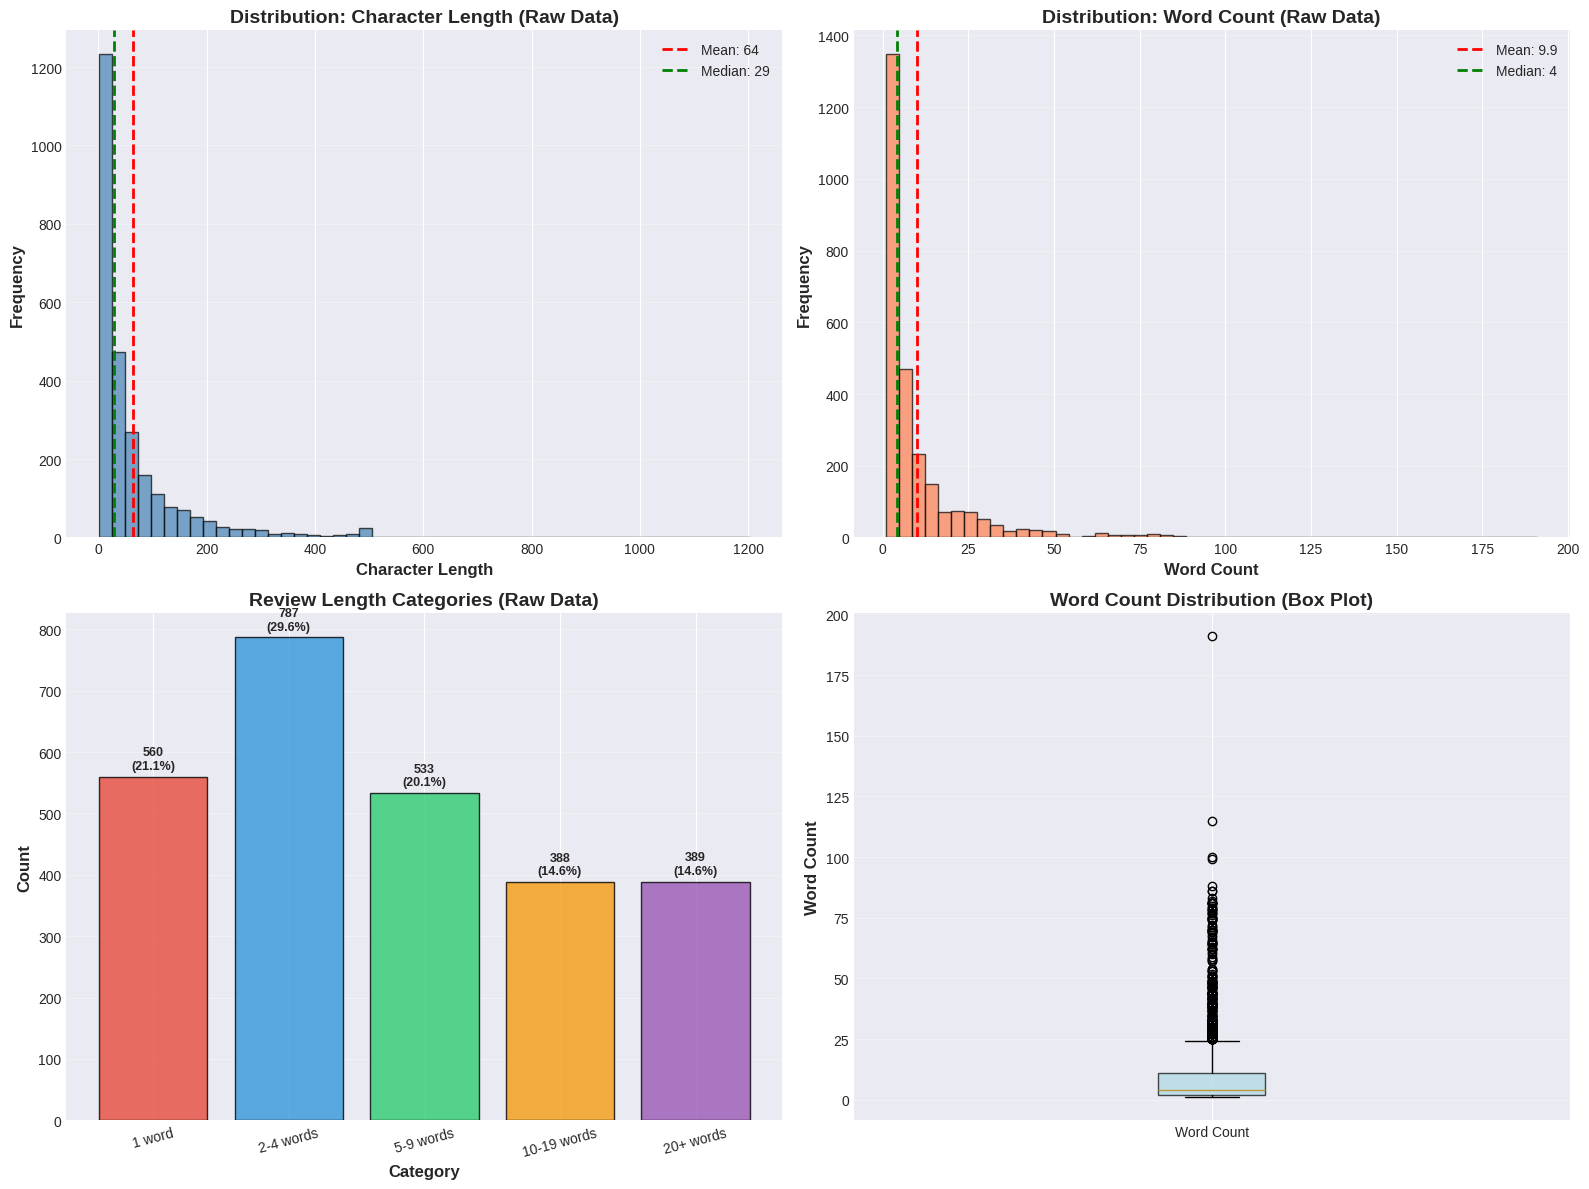

✓ Visualisasi disimpan: 01_eda_raw_data.png


In [ ]:
# ── Visualisasi EDA (2x2) ────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Character length histogram
ax1 = axes[0, 0]
ax1.hist(df['char_length'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(df['char_length'].mean(),   color='red',   linestyle='--', linewidth=2,
            label=f'Mean: {df["char_length"].mean():.0f}')
ax1.axvline(df['char_length'].median(), color='green', linestyle='--', linewidth=2,
            label=f'Median: {df["char_length"].median():.0f}')
ax1.set_xlabel('Character Length', fontsize=12, fontweight='bold')
ax1.set_ylabel('Frequency',        fontsize=12, fontweight='bold')
ax1.set_title('Distribution: Character Length (Raw Data)', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 2. Word count histogram
ax2 = axes[0, 1]
ax2.hist(df['word_count'], bins=50, color='coral', edgecolor='black', alpha=0.7)
ax2.axvline(df['word_count'].mean(),   color='red',   linestyle='--', linewidth=2,
            label=f'Mean: {df["word_count"].mean():.1f}')
ax2.axvline(df['word_count'].median(), color='green', linestyle='--', linewidth=2,
            label=f'Median: {df["word_count"].median():.0f}')
ax2.set_xlabel('Word Count', fontsize=12, fontweight='bold')
ax2.set_ylabel('Frequency',  fontsize=12, fontweight='bold')
ax2.set_title('Distribution: Word Count (Raw Data)', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 3. Word count categories
ax3 = axes[1, 0]
categories = ['1 word', '2-4 words', '5-9 words', '10-19 words', '20+ words']
counts = [
    (df['word_count'] == 1).sum(),
    ((df['word_count'] >= 2)  & (df['word_count'] <= 4)).sum(),
    ((df['word_count'] >= 5)  & (df['word_count'] <= 9)).sum(),
    ((df['word_count'] >= 10) & (df['word_count'] <= 19)).sum(),
    (df['word_count'] >= 20).sum()
]
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
bars   = ax3.bar(categories, counts, color=colors, edgecolor='black', alpha=0.8)
ax3.set_xlabel('Category', fontsize=12, fontweight='bold')
ax3.set_ylabel('Count',    fontsize=12, fontweight='bold')
ax3.set_title('Review Length Categories (Raw Data)', fontsize=14, fontweight='bold')
ax3.tick_params(axis='x', rotation=15)
ax3.grid(axis='y', alpha=0.3)
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + max(counts)*0.01,
             f'{count:,}\n({count/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontweight='bold', fontsize=9)

# 4. Box plot
ax4 = axes[1, 1]
bp  = ax4.boxplot([df['word_count']], vert=True, patch_artist=True, labels=['Word Count'])
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][0].set_alpha(0.7)
ax4.set_ylabel('Word Count', fontsize=12, fontweight='bold')
ax4.set_title('Word Count Distribution (Box Plot)', fontsize=14, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('01_eda_raw_data.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Visualisasi disimpan: 01_eda_raw_data.png")

**Word Cloud - Raw Data**


🔄 Preparing text for word cloud...
🔄 Generating word cloud...


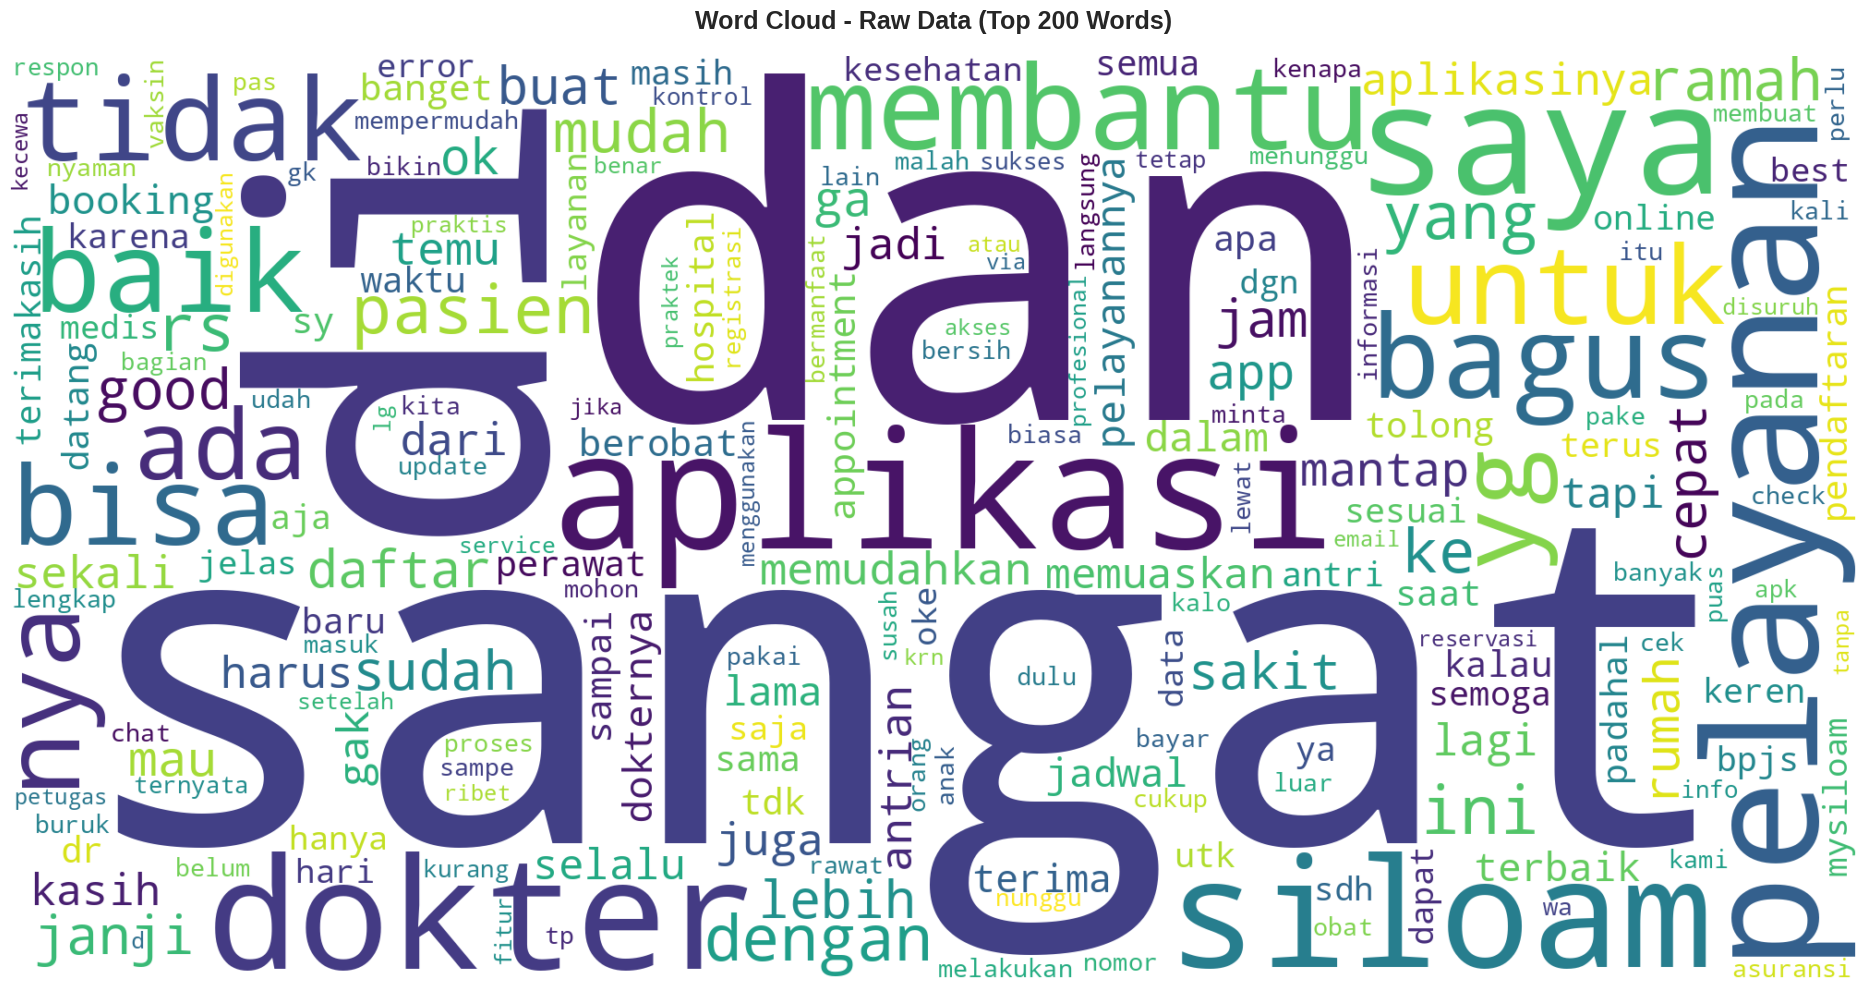

✓ Visualisasi disimpan: 02_wordcloud_raw_data.png

📊 Top 20 Words in Raw Data:
    Rank Word                  Frequency
   --------------------------------------
       1 sangat                      675
       2 dan                         652
       3 di                          505
       4 aplikasi                    407
       5 pelayanan                   379
       6 dokter                      361
       7 saya                        361
       8 siloam                      347
       9 membantu                    308
      10 bagus                       298
      11 tidak                       294
      12 baik                        290
      13 bisa                        269
      14 untuk                       262
      15 nya                         251
      16 yg                          233
      17 ada                         209
      18 pasien                      208
      19 ini                         203
      20 rs                          190


In [ ]:
# ── Word Cloud ───────────────────────────────────────────────────
def simple_clean_for_wordcloud(text):
    if pd.isna(text): return ""
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("\n🔄 Preparing text for word cloud...")
df['text_for_wordcloud'] = df['content'].apply(simple_clean_for_wordcloud)
all_text_raw = ' '.join(df['text_for_wordcloud'])

print("🔄 Generating word cloud...")
wordcloud_raw = WordCloud(
    width=2000, height=1000,
    background_color='white',
    colormap='viridis',
    max_words=200,
    relative_scaling=0.5,
    collocations=False,
    min_font_size=10
).generate(all_text_raw)

plt.figure(figsize=(20, 10))
plt.imshow(wordcloud_raw, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Raw Data (Top 200 Words)', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('02_wordcloud_raw_data.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Visualisasi disimpan: 02_wordcloud_raw_data.png")

# Top 20 words
word_freq_raw = Counter(all_text_raw.split())
print(f"\n📊 Top 20 Words in Raw Data:")
print(f"   {'Rank':>5s} {'Word':20s} {'Frequency':>10s}")
print("   " + "-" * 38)
for rank, (word, freq) in enumerate(word_freq_raw.most_common(20), 1):
    print(f"   {rank:5d} {word:20s} {freq:>10,}")

df = df.drop(columns=['text_for_wordcloud'])

# **DATA PREPROCESSING**

In [ ]:
!pip install PySastrawi googletrans==4.0.0-rc1 wordcloud -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter
from wordcloud import WordCloud
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from googletrans import Translator
import time

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.6/210.6 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 3.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-genai 1.68.0 requires httpx<1.0.0,>=0.28.1, but you have httpx 0.13.3 which is incompatible.
mcp 1.26.0 requires httpx>=0.27.1, but you have httpx 0.

## **UBAH KATA BIG KE B.INDO**

In [ ]:
# ── Step 1: Kamus Manual dulu (lebih cepat & hemat API) ───────────
english_to_id = {
    "very good"     : "sangat baik",
    "the best"      : "terbaik",
    "excellent"     : "sangat baik",
    "helpful"       : "sangat membantu",
    "helpfull"      : "sangat membantu",
    "good"          : "baik",
    "great"         : "bagus",
    "best"          : "terbaik",
    "nice"          : "baik",
    "bad"           : "buruk",
    "slow"          : "lambat",
    "fast"          : "cepat",
    "easy"          : "mudah",
    "very"          : "sangat",
    "user friendly" : "mudah digunakan",
    "really"        : "sangat",
    "poor"          : "buruk",
    "simple"        : "sederhana",
    "practical"     : "praktis",
    "app"           : "aplikasi",
    "service"       : "layanan",
    "hospital"      : "rumah sakit",
    "doctor"        : "dokter",
    "helpful"       : "membantu",
}

def normalize_english(text):
    text = str(text).lower()
    for eng, indo in english_to_id.items():
        text = re.sub(r'\b' + re.escape(eng) + r'\b', indo, text)
    return text

df_translate = df_raw[['content']].copy()
df_translate['content'] = df_translate['content'].apply(normalize_english)

print("✓ Step 1: Normalisasi kamus manual selesai")

# ── Step 2: Google Translate semua review ────────────────────────
translator = Translator()

def translate_to_indonesia(text):
    try:
        hasil = translator.translate(str(text), dest='id')
        time.sleep(0.1)   # hindari rate limit
        return hasil.text
    except Exception as e:
        return text       # kalau gagal, kembalikan teks asli

print("\n🔄 Step 2: Google Translate sedang berjalan...")
print("   (Proses ini memakan waktu, harap tunggu...)")

df_translate['content'] = df_translate['content'].apply(translate_to_indonesia)

print("✓ Google Translate selesai")

# ── Simpan hasil translate ────────────────────────────────────────
df_translate.to_csv('dataset_after_translate.csv', index=False, encoding='utf-8-sig')

print(f"\n📁 Disimpan ke: dataset_after_translate.csv")
print(f"   Total baris: {len(df_translate):,}")

print(f"\n📝 Sample Data SETELAH translate (5 baris):")
print("="*80)
for i in range(min(5, len(df_translate))):
    original = df_raw['content'].iloc[i]
    hasil    = df_translate['content'].iloc[i]
    print(f"{i+1}. ASLI  : {original}")
    print(f"   HASIL : {hasil}")
    print()
print("="*80)

✓ Step 1: Normalisasi kamus manual selesai

🔄 Step 2: Google Translate sedang berjalan...
   (Proses ini memakan waktu, harap tunggu...)
✓ Google Translate selesai

📁 Disimpan ke: dataset_after_translate.csv
   Total baris: 2,657

📝 Sample Data SETELAH translate (5 baris):
1. ASLI  : setiap mau masuk ke beranda selalu loadingg
   HASIL : setiap mau masuk ke beranda selalu loadingg

2. ASLI  : Aplikasi RS terbaik...
   HASIL : aplikasi rs terbaik...

3. ASLI  : aplikasi lengkap, fitur andalan dan sangat informatif
   HASIL : aplikasi lengkap, fitur andalan dan sangat informatif

4. ASLI  : ok
   HASIL : Oke

5. ASLI  : good
   HASIL : baik



In [ ]:
# ── Simpan ke Excel ───────────────────────────────────────────────
output_file = "dataset_after_translate.xlsx"
df_translate.to_excel(output_file, index=False)

print(f"\n📁 File Excel berhasil disimpan: {output_file}")


# ── Tampilkan preview dataframe ───────────────────────────────────
print("\n🔍 Preview Data (10 baris pertama):")
print(df_translate.head(10))


# ── Bandingkan sebelum vs sesudah translate ───────────────────────
df_compare = pd.DataFrame({
    "SEBELUM": df_raw["content"],
    "SESUDAH": df_translate["content"]
})

print("\n📊 Perbandingan sebelum vs sesudah (5 data):")
print(df_compare.head())


# ── (Opsional) Simpan juga versi perbandingan ke Excel ────────────
df_compare.to_excel("compare_translate.xlsx", index=False)

print("\n📁 File perbandingan disimpan: compare_translate.xlsx")


📁 File Excel berhasil disimpan: dataset_after_translate.xlsx

🔍 Preview Data (10 baris pertama):
                                                 content
0            setiap mau masuk ke beranda selalu loadingg
1                                 aplikasi rs terbaik...
2  aplikasi lengkap, fitur andalan dan sangat informatif
3                                                    Oke
4                                                   baik
5                  sangat memudahkan ,terimakasih siloam
6                                        mudah dan cepat
7                        pelayanan prima ramah memuaskan
8                                      pelayanannya baik
9                                                  bagus

📊 Perbandingan sebelum vs sesudah (5 data):
                                                 SEBELUM  \
0            setiap mau masuk ke beranda selalu loadingg   
1                                 Aplikasi RS terbaik...   
2  aplikasi lengkap, fitur andalan dan sangat info

## **CASE FOLDING**

In [ ]:
print("Tujuan: Mengubah semua huruf menjadi lowercase untuk standardisasi")

df_prep = df_translate.copy()
df_prep['case_folding'] = df_prep['content'].astype(str).str.lower()

print("\n✓ Case folding selesai")

unique_before = df_prep['content'].astype(str).apply(lambda x: len(set(x))).mean()
unique_after  = df_prep['case_folding'].apply(lambda x: len(set(x))).mean()

print(f"\n📊 Rata-rata unique characters:")
print(f"   Sebelum: {unique_before:.1f}")
print(f"   Sesudah: {unique_after:.1f}")

print(f"\n📝 Sample Data SETELAH case folding:")
print("="*80)
for i in range(min(5, len(df_prep))):
    print(f"{i+1}. {df_prep['case_folding'].iloc[i]}")
print("="*80)

Tujuan: Mengubah semua huruf menjadi lowercase untuk standardisasi

✓ Case folding selesai

📊 Rata-rata unique characters:
   Sebelum: 14.5
   Sesudah: 14.4

📝 Sample Data SETELAH case folding:
1. setiap mau masuk ke beranda selalu loadingg
2. aplikasi rs terbaik...
3. aplikasi lengkap, fitur andalan dan sangat informatif
4. oke
5. baik


## **CLEANING**

In [ ]:
slang_dict = {
    "yg"     : "yang",   "dgn"    : "dengan",  "utk"   : "untuk",
    "tdk"    : "tidak",  "gak"    : "tidak",   "ga"    : "tidak",
    "gk"     : "tidak",  "ngga"   : "tidak",   "nggak" : "tidak",
    "enggak" : "tidak",  "bgt"    : "banget",  "bngt"  : "banget",
    "dpt"    : "dapat",  "bs"     : "bisa",    "bsa"   : "bisa",
    "sm"     : "sama",   "jd"     : "jadi",    "udh"   : "sudah",
    "sdh"    : "sudah",  "udah"   : "sudah",   "dah"   : "sudah",
    "blm"    : "belum",  "krn"    : "karena",  "karna" : "karena",
    "emg"    : "memang", "msh"    : "masih",   "lg"    : "lagi",
    "aja"    : "saja",   "aj"     : "saja",    "jg"    : "juga",
    "tp"     : "tapi",   "klo"    : "kalau",   "kl"    : "kalau",
    "skrg"   : "sekarang","kmrn"  : "kemarin", "mo"    : "mau",
    "sy"     : "saya",   "aq"     : "saya",    "ak"    : "saya",
    "km"     : "kamu",   "lo"     : "kamu",    "lu"    : "kamu",
    "dok"    : "dokter", "dktr"   : "dokter",
    "rs"     : "rumah sakit",
    "trmksh" : "terima kasih", "makasih" : "terima kasih",
    "thx"    : "terima kasih", "thanks"  : "terima kasih",
    "oke"    : "ok",     "okey"   : "ok",      "okay"  : "ok",
    "mantep" : "mantap", "kereeen": "keren",   "kereen": "keren",
    "baguss" : "bagus",  "bagusss": "bagus",
    "lelet"  : "lambat", "loadingg": "loading",
    "ribet"  : "rumit",  "susah"  : "sulit",
}

def normalize_slang(text):
    tokens = text.split()
    return ' '.join([slang_dict.get(word, word) for word in tokens])

df_prep['normalize'] = df_prep['case_folding'].apply(normalize_slang)

print("✓ Normalisasi slang selesai")
print(f"📊 Kamus slang: {len(slang_dict)} entri")

print(f"\n📝 Sample SETELAH normalisasi slang:")
print("="*80)
for i in range(min(5, len(df_prep))):
    print(f"{i+1}. {df_prep['normalize'].iloc[i]}")
print("="*80)

✓ Normalisasi slang selesai
📊 Kamus slang: 61 entri

📝 Sample SETELAH normalisasi slang:
1. setiap mau masuk ke beranda selalu loading
2. aplikasi rumah sakit terbaik...
3. aplikasi lengkap, fitur andalan dan sangat informatif
4. ok
5. baik


In [ ]:
print("Tujuan: Membersihkan teks dari elemen yang tidak diperlukan")
print("""
Yang akan dihapus:
  • URL (http://, www., https://)
  • Mention (@username) & Hashtag (#tag)
  • Angka (0-9)
  • Emoji & karakter khusus
  • Spasi berlebih
  • Review < 3 kata (tidak cukup untuk analisis multi-aspek)
""")

def cleaning_text(text):
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("🔄 Proses cleaning...")
df_prep['cleaning'] = df_prep['normalize'].apply(cleaning_text)

avg_before = df_prep['normalize'].apply(len).mean()
avg_after  = df_prep['cleaning'].apply(len).mean()
reduction  = ((avg_before - avg_after) / avg_before) * 100

print("✓ Cleaning selesai")
print(f"\n📊 Rata-rata panjang karakter:")
print(f"   Sebelum : {avg_before:.1f}")
print(f"   Sesudah : {avg_after:.1f}")
print(f"   Reduksi : {reduction:.1f}%")

# ── Filter review < 3 kata ────────────────────────────────────────
before_filter = len(df_prep)
df_prep['word_count_clean'] = df_prep['cleaning'].apply(lambda x: len(x.split()))

print(f"\n🔍 Distribusi panjang review setelah cleaning:")
print(f"   {'Kategori':<20} {'Jumlah':>8} {'Persen':>8}")
print("   " + "-"*38)
for label, mask in [
    ("< 3 kata",   df_prep['word_count_clean'] < 3),
    ("3–5 kata",  (df_prep['word_count_clean'] >= 3) & (df_prep['word_count_clean'] <= 5)),
    ("6–10 kata", (df_prep['word_count_clean'] >= 6) & (df_prep['word_count_clean'] <= 10)),
    ("11–20 kata",(df_prep['word_count_clean'] >= 11) & (df_prep['word_count_clean'] <= 20)),
    ("> 20 kata",  df_prep['word_count_clean'] > 20),
]:
    cnt = mask.sum()
    print(f"   {label:<20} {cnt:>8,} {cnt/len(df_prep)*100:>7.1f}%")

df_prep = df_prep[df_prep['word_count_clean'] >= 3].copy()
df_prep.drop(columns=['word_count_clean'], inplace=True)

after_filter = len(df_prep)

print(f"\n🧹 Hasil Filter Review Pendek (< 3 kata):")
print(f"   Sebelum filter : {before_filter:,}")
print(f"   Sesudah filter : {after_filter:,}")
print(f"   Dihapus        : {before_filter - after_filter:,} review")

df_prep.to_csv('dataset_after_cleaning.csv', index=False, encoding='utf-8-sig')
print(f"\n📁 Disimpan ke: dataset_after_cleaning.csv")

# ── Tambahan: Simpan ke Excel ─────────────────────────────────────
excel_file = "dataset_after_cleaning.xlsx"
df_prep.to_excel(excel_file, index=False)

print(f"\n📁 File disimpan:")
print(f"   - dataset_after_cleaning.csv")
print(f"   - {excel_file}")

print(f"\n📝 Sample Data SETELAH cleaning:")
print("="*80)
for i in range(min(5, len(df_prep))):
    print(f"{i+1}. {df_prep['cleaning'].iloc[i]}")
print("="*80)

Tujuan: Membersihkan teks dari elemen yang tidak diperlukan

Yang akan dihapus:
  • URL (http://, www., https://)
  • Mention (@username) & Hashtag (#tag)
  • Angka (0-9)
  • Emoji & karakter khusus
  • Spasi berlebih
  • Review < 3 kata (tidak cukup untuk analisis multi-aspek)

🔄 Proses cleaning...
✓ Cleaning selesai

📊 Rata-rata panjang karakter:
   Sebelum : 66.1
   Sesudah : 63.9
   Reduksi : 3.3%

🔍 Distribusi panjang review setelah cleaning:
   Kategori               Jumlah   Persen
   --------------------------------------
   < 3 kata                  958    36.1%
   3–5 kata                  550    20.7%
   6–10 kata                 437    16.4%
   11–20 kata                335    12.6%
   > 20 kata                 377    14.2%

🧹 Hasil Filter Review Pendek (< 3 kata):
   Sebelum filter : 2,657
   Sesudah filter : 1,699
   Dihapus        : 958 review

📁 Disimpan ke: dataset_after_cleaning.csv

📁 File disimpan:
   - dataset_after_cleaning.csv
   - dataset_after_cleaning.xlsx

📝 

## **TOKENIZING**

In [ ]:
print("Tujuan: Memecah teks menjadi list kata-kata (tokens)")

df_prep_new = df_prep.copy()

print("🔄 Proses tokenizing...")
df_prep_new['tokenizing'] = df_prep_new['cleaning'].apply(lambda x: x.split())

total_tokens  = df_prep_new['tokenizing'].apply(len).sum()
avg_tokens    = df_prep_new['tokenizing'].apply(len).mean()
unique_tokens = len(set(w for tokens in df_prep_new['tokenizing'] for w in tokens))

print("✓ Tokenizing selesai")
print(f"\n📊 Statistik Tokenisasi:")
print(f"   Total tokens       : {total_tokens:,}")
print(f"   Unique tokens      : {unique_tokens:,}")
print(f"   Avg tokens/review  : {avg_tokens:.1f}")

print(f"\n📝 Sample Data SETELAH tokenizing:")
print("="*80)
for i in range(min(5, len(df_prep_new))):
    print(f"{i+1}. {df_prep_new['tokenizing'].iloc[i]}")
print("="*80)

Tujuan: Memecah teks menjadi list kata-kata (tokens)
🔄 Proses tokenizing...
✓ Tokenizing selesai

📊 Statistik Tokenisasi:
   Total tokens       : 24,966
   Unique tokens      : 3,650
   Avg tokens/review  : 14.7

📝 Sample Data SETELAH tokenizing:
1. ['setiap', 'mau', 'masuk', 'ke', 'beranda', 'selalu', 'loading']
2. ['aplikasi', 'rumah', 'sakit', 'terbaik']
3. ['aplikasi', 'lengkap', 'fitur', 'andalan', 'dan', 'sangat', 'informatif']
4. ['sangat', 'memudahkan', 'terimakasih', 'siloam']
5. ['mudah', 'dan', 'cepat']


## **STOPWORD REMOVAL**

In [ ]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
print("Tujuan: Menghapus kata-kata umum yang tidak bermakna")

factory_stopword = StopWordRemoverFactory()
stopwords_id     = factory_stopword.get_stop_words()

additional_stopwords = [
    'yg','nya','dgn','utk','ttg','yaa','yahh','yaaa',
    'aja','nih','sih','deh','dong','kok','lah',
    'hehe','wkwk','haha','u','x','ok',
    'mysiloam','siloam','rs',
    'the','so','this','that','and','or','but',
    'really','very','all','is','di','ke','dan',
    'cukup','banget','sekali','lumayan','sangat',
    'saya','sy','dn',
]

all_stopwords = set(stopwords_id + additional_stopwords)

print(f"\n📊 Stopwords:")
print(f"   Sastrawi  : {len(stopwords_id)}")
print(f"   Tambahan  : {len(additional_stopwords)}")
print(f"   Total     : {len(all_stopwords)}")

print("\n🔄 Proses stopword removal...")
df_prep_new['stopword_removal'] = df_prep_new['tokenizing'].apply(
    lambda tokens: [w for w in tokens if w not in all_stopwords]
)
print("✓ Stopword removal selesai")

total_after  = df_prep_new['stopword_removal'].apply(len).sum()
avg_after_sw = df_prep_new['stopword_removal'].apply(len).mean()
unique_after = len(set(w for tokens in df_prep_new['stopword_removal'] for w in tokens))
sw_reduction = ((total_tokens - total_after) / total_tokens) * 100

print(f"\n📊 Statistik Stopword Removal:")
print(f"   Total tokens sebelum  : {total_tokens:,}")
print(f"   Total tokens sesudah  : {total_after:,}")
print(f"   Tokens dihapus        : {total_tokens - total_after:,}")
print(f"   Reduksi tokens        : {sw_reduction:.1f}%")
print(f"   Unique tokens sesudah : {unique_after:,}")
print(f"   Avg tokens/review     : {avg_after_sw:.1f}")

print(f"\n📝 Contoh Transformasi:")
print("="*80)
print(f"SEBELUM : {df_prep_new['tokenizing'].iloc[0]}")
print(f"SESUDAH : {df_prep_new['stopword_removal'].iloc[0]}")
print("="*80)

df_prep_new['stopword_removal'].to_csv(
    'dataset_after_stopwordremoval.csv', index=False, encoding='utf-8-sig'
)
print(f"\n📁 Disimpan ke: dataset_after_stopwordremoval.csv")

Tujuan: Menghapus kata-kata umum yang tidak bermakna

📊 Stopwords:
   Sastrawi  : 126
   Tambahan  : 46
   Total     : 164

🔄 Proses stopword removal...
✓ Stopword removal selesai

📊 Statistik Stopword Removal:
   Total tokens sebelum  : 24,966
   Total tokens sesudah  : 17,042
   Tokens dihapus        : 7,924
   Reduksi tokens        : 31.7%
   Unique tokens sesudah : 3,508
   Avg tokens/review     : 10.0

📝 Contoh Transformasi:
SEBELUM : ['setiap', 'mau', 'masuk', 'ke', 'beranda', 'selalu', 'loading']
SESUDAH : ['mau', 'masuk', 'beranda', 'selalu', 'loading']

📁 Disimpan ke: dataset_after_stopwordremoval.csv


## **STEMMING**

### **SCENARIO 1: DATA TANPA STEMMING**

✓ Scenario 1 (Tanpa Stemming) selesai
📊 Shape : (1699, 1)

📝 Contoh Hasil Akhir:
   ORIGINAL : setiap mau masuk ke beranda selalu loading
   CLEANED  : mau masuk beranda selalu loading

📊 Analisis Vocabulary (Tanpa Stemming):
   Total words      : 17,042
   Unique words     : 3,508
   Avg words/review : 10.0

📊 Top 20 Kata (Tanpa Stemming):
     No Kata                    Frekuensi
   --------------------------------------
      1 aplikasi                      468
      2 dokter                        369
      3 pelayanan                     343
      4 sakit                         314
      5 rumah                         304
      6 membantu                      253
      7 baik                          250
      8 pasien                        212
      9 bagus                         200
     10 mudah                         161
     11 ramah                         154
     12 janji                         144
     13 cepat                         132
     14 jam                

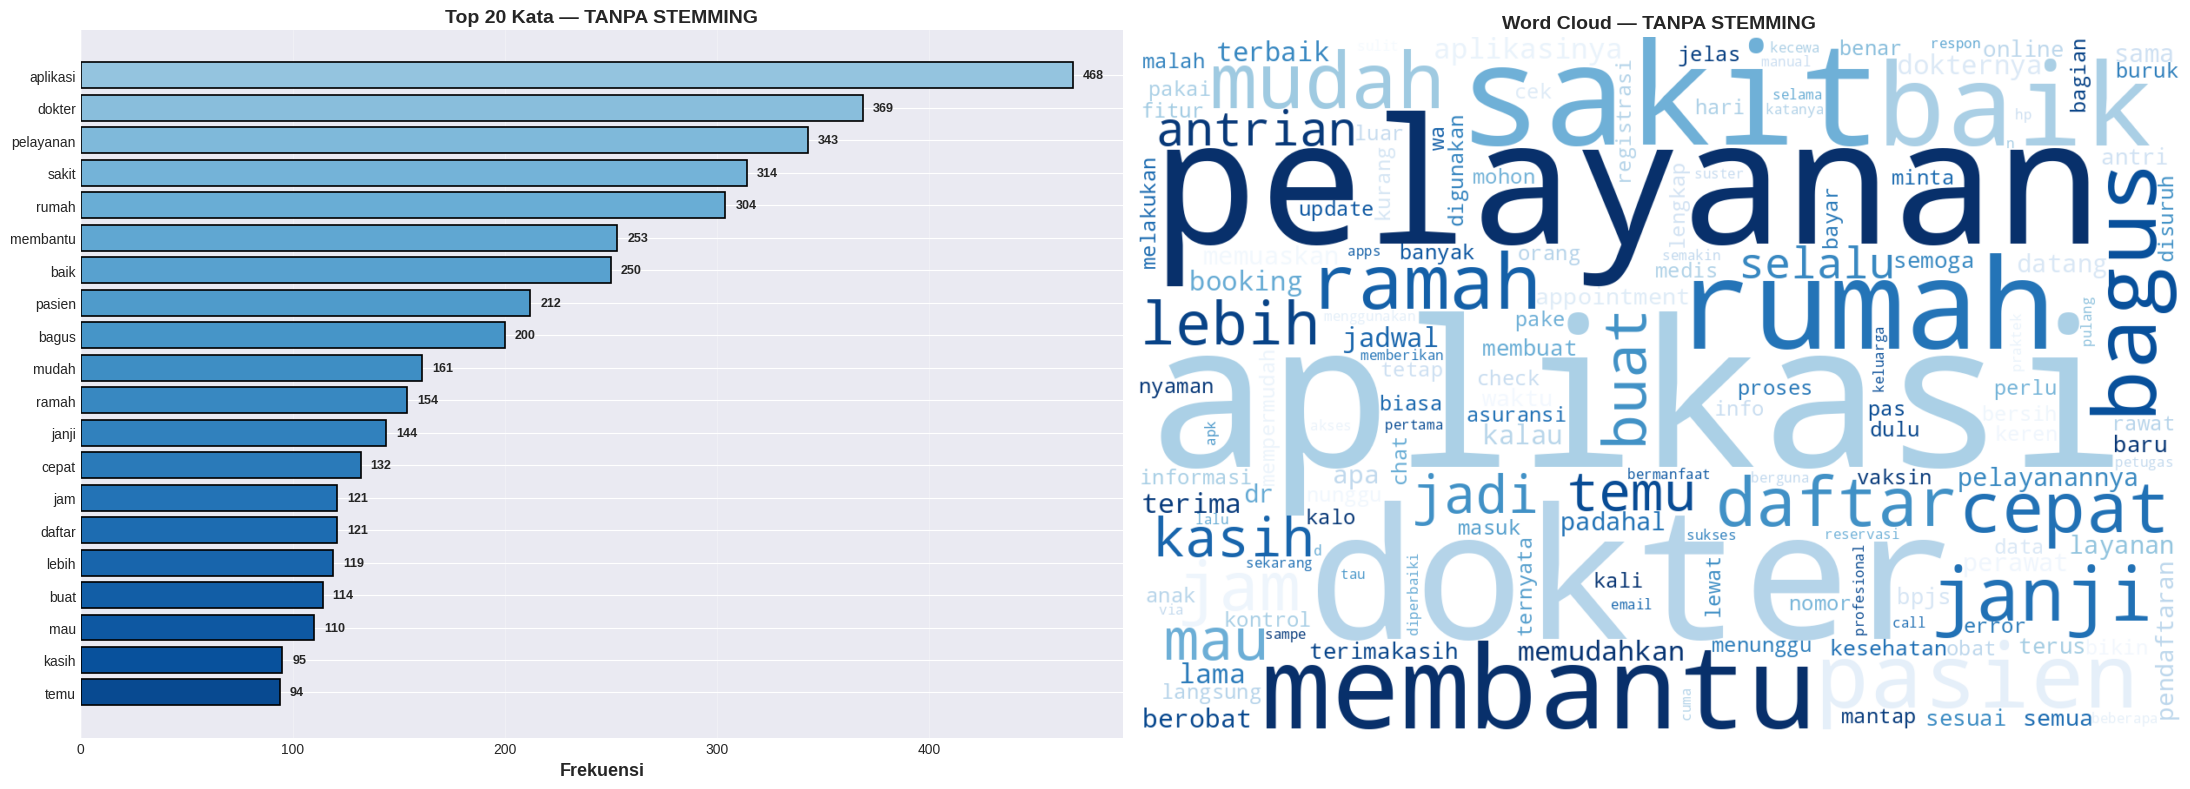

✓ Visualisasi disimpan: 07_scenario1_no_stemming.png


In [ ]:
df_prep_new['text_clean'] = df_prep_new['stopword_removal'].apply(lambda x: ' '.join(x))

df_scenario1 = df_prep_new[['text_clean']].copy()
df_scenario1.columns = ['clean_text']
df_scenario1.to_csv('data_clean_no_stemming.csv', index=False, encoding='utf-8-sig')

print("✓ Scenario 1 (Tanpa Stemming) selesai")
print(f"📊 Shape : {df_scenario1.shape}")
print(f"\n📝 Contoh Hasil Akhir:")
print(f"   ORIGINAL : {df_prep_new['cleaning'].iloc[0][:100]}")
print(f"   CLEANED  : {df_prep_new['text_clean'].iloc[0][:100]}")

all_words_no_stem = [w for tokens in df_prep_new['stopword_removal'] for w in tokens]
word_freq_no_stem = Counter(all_words_no_stem)
top_20_no_stem    = word_freq_no_stem.most_common(20)

print(f"\n📊 Analisis Vocabulary (Tanpa Stemming):")
print(f"   Total words      : {len(all_words_no_stem):,}")
print(f"   Unique words     : {len(word_freq_no_stem):,}")
print(f"   Avg words/review : {len(all_words_no_stem)/len(df_prep_new):.1f}")

print(f"\n📊 Top 20 Kata (Tanpa Stemming):")
print(f"   {'No':>4} {'Kata':20} {'Frekuensi':>12}")
print("   " + "-"*38)
for i, (word, freq) in enumerate(top_20_no_stem, 1):
    print(f"   {i:>4d} {word:20} {freq:>12,}")

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

ax = axes[0]
words_ns, counts_ns = zip(*top_20_no_stem)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, 20))
ax.barh(words_ns, counts_ns, color=colors, edgecolor='black', linewidth=1.2)
ax.set_xlabel('Frekuensi', fontsize=13, fontweight='bold')
ax.set_title('Top 20 Kata — TANPA STEMMING', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
for i, (w, c) in enumerate(zip(words_ns, counts_ns)):
    ax.text(c + max(counts_ns)*0.01, i, f'{c:,}', va='center', fontsize=9, fontweight='bold')

ax2 = axes[1]
wc = WordCloud(width=1200, height=800, background_color='white',
               colormap='Blues', max_words=150, collocations=False
               ).generate(' '.join(df_prep_new['text_clean']))
ax2.imshow(wc, interpolation='bilinear')
ax2.axis('off')
ax2.set_title('Word Cloud — TANPA STEMMING', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('07_scenario1_no_stemming.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Visualisasi disimpan: 07_scenario1_no_stemming.png")

### **SCENARIO 2: DATA DENGAN STEMMING**

🔄 Proses stemming... (mungkin beberapa menit)
✓ Stemming selesai

📝 Contoh Stemming Kata:
   Original             → Stem           
   -------------------------------------
   membantu             → bantu          
   pelayanan            → layan          
   melakukan            → laku           
   pembuatan            → buat           
   mengecewakan         → kecewa         
   pendaftaran          → daftar         

📝 Contoh Transformasi Review:
SEBELUM : ['mau', 'masuk', 'beranda', 'selalu', 'loading']
SESUDAH : ['mau', 'masuk', 'beranda', 'selalu', 'loading']

✓ Scenario 2 (Dengan Stemming) selesai
📊 Shape : (1699, 1)

📊 Analisis Vocabulary (Dengan Stemming):
   Total words      : 17,042
   Unique words     : 2,723
   Avg words/review : 10.0

📊 Top 20 Kata (Dengan Stemming):
     No Kata                    Frekuensi
   --------------------------------------
      1 aplikasi                      552
      2 layan                         502
      3 dokter                        

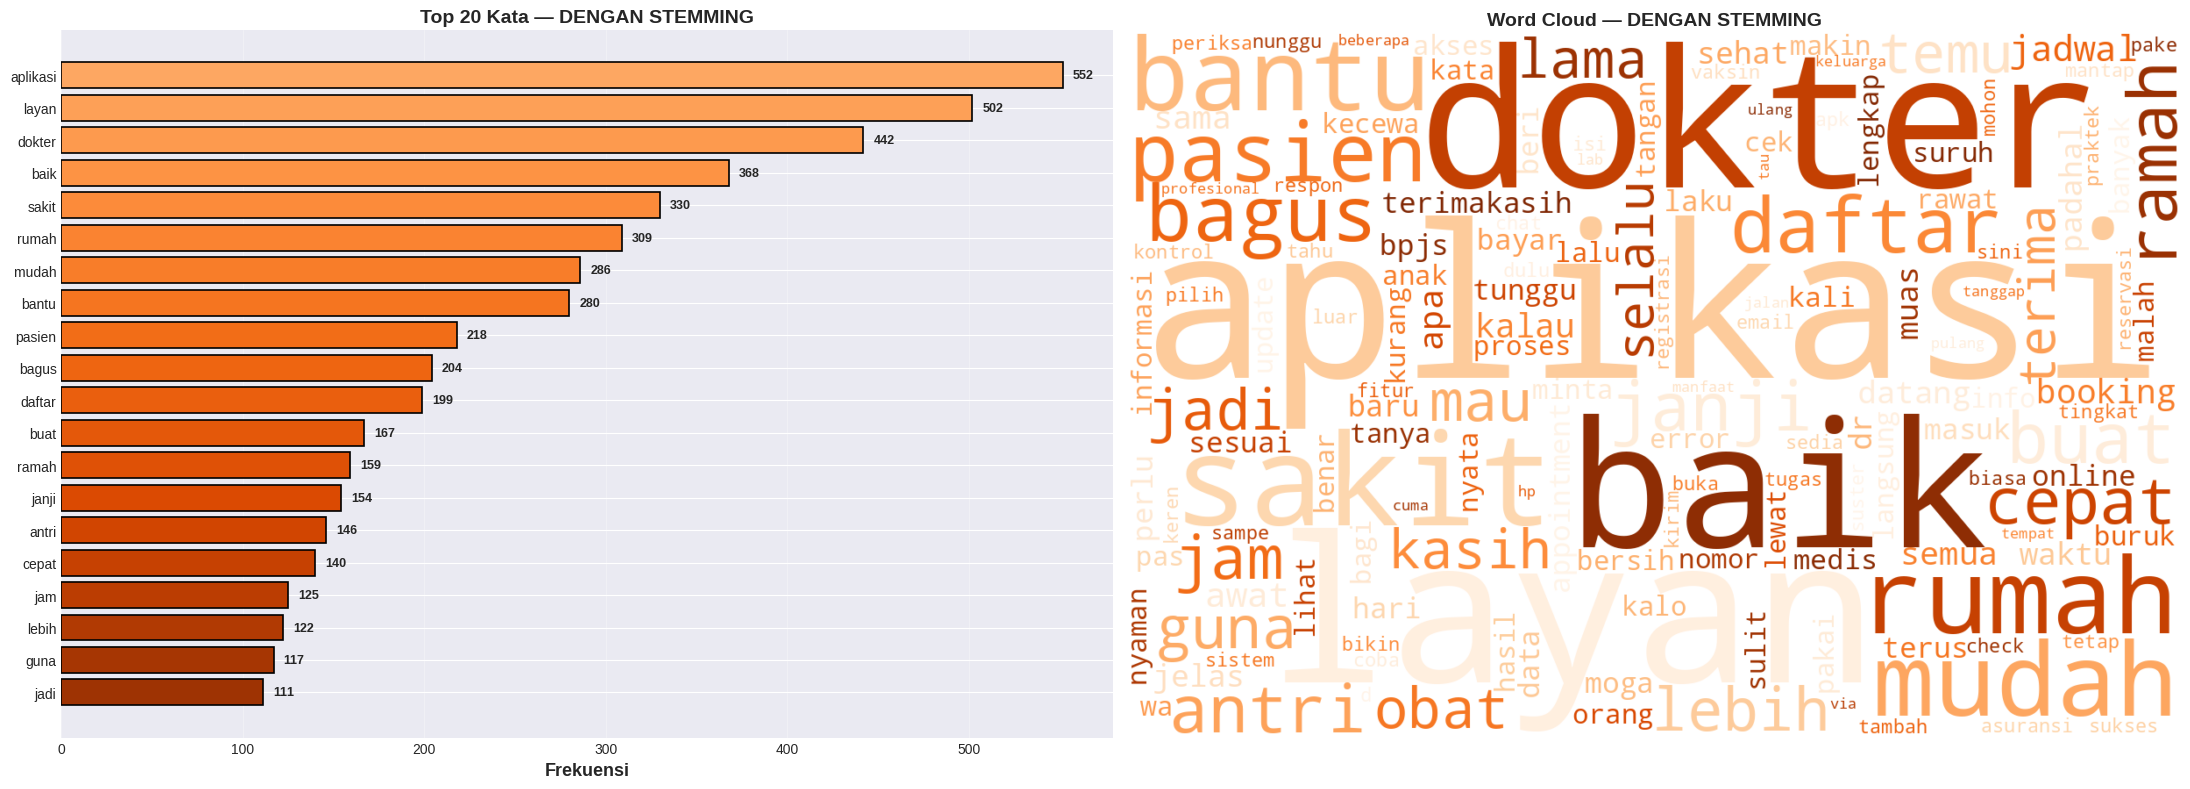

✓ Visualisasi disimpan: 08_scenario2_with_stemming.png


In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
factory_stemmer = StemmerFactory()
stemmer         = factory_stemmer.create_stemmer()

print("🔄 Proses stemming... (mungkin beberapa menit)")
df_prep_new['stemming'] = df_prep_new['stopword_removal'].apply(
    lambda tokens: [stemmer.stem(w) for w in tokens]
)
print("✓ Stemming selesai")

print("\n📝 Contoh Stemming Kata:")
sample_words = ['membantu','pelayanan','melakukan','pembuatan','mengecewakan','pendaftaran']
print(f"   {'Original':20} → {'Stem':15}")
print("   " + "-"*37)
for word in sample_words:
    print(f"   {word:20} → {stemmer.stem(word):15}")

print(f"\n📝 Contoh Transformasi Review:")
print("="*80)
print(f"SEBELUM : {df_prep_new['stopword_removal'].iloc[0]}")
print(f"SESUDAH : {df_prep_new['stemming'].iloc[0]}")
print("="*80)

df_prep_new['text_stemmed'] = df_prep_new['stemming'].apply(lambda x: ' '.join(x))
df_scenario2 = df_prep_new[['text_stemmed']].copy()
df_scenario2.columns = ['clean_text']
df_scenario2.to_csv('data_clean_with_stemming.csv', index=False, encoding='utf-8-sig')

print(f"\n✓ Scenario 2 (Dengan Stemming) selesai")
print(f"📊 Shape : {df_scenario2.shape}")

all_words_stem = [w for tokens in df_prep_new['stemming'] for w in tokens]
word_freq_stem = Counter(all_words_stem)
top_20_stem    = word_freq_stem.most_common(20)

print(f"\n📊 Analisis Vocabulary (Dengan Stemming):")
print(f"   Total words      : {len(all_words_stem):,}")
print(f"   Unique words     : {len(word_freq_stem):,}")
print(f"   Avg words/review : {len(all_words_stem)/len(df_prep_new):.1f}")

print(f"\n📊 Top 20 Kata (Dengan Stemming):")
print(f"   {'No':>4} {'Kata':20} {'Frekuensi':>12}")
print("   " + "-"*38)
for i, (word, freq) in enumerate(top_20_stem, 1):
    print(f"   {i:>4d} {word:20} {freq:>12,}")

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

ax = axes[0]
words_s, counts_s = zip(*top_20_stem)
colors = plt.cm.Oranges(np.linspace(0.4, 0.9, 20))
ax.barh(words_s, counts_s, color=colors, edgecolor='black', linewidth=1.2)
ax.set_xlabel('Frekuensi', fontsize=13, fontweight='bold')
ax.set_title('Top 20 Kata — DENGAN STEMMING', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
for i, (w, c) in enumerate(zip(words_s, counts_s)):
    ax.text(c + max(counts_s)*0.01, i, f'{c:,}', va='center', fontsize=9, fontweight='bold')

ax2 = axes[1]
wc2 = WordCloud(width=1200, height=800, background_color='white',
                colormap='Oranges', max_words=150, collocations=False
                ).generate(' '.join(df_prep_new['text_stemmed']))
ax2.imshow(wc2, interpolation='bilinear')
ax2.axis('off')
ax2.set_title('Word Cloud — DENGAN STEMMING', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('08_scenario2_with_stemming.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Visualisasi disimpan: 08_scenario2_with_stemming.png")